# Introduction

The aim of this study is to analyze the distribution of daily returns of the WIG20 index over an eight-year period (2015-01-01 to 2023-01-01). The WIG20 is a stock market index comprising the twenty largest publicly traded companies listed on the Warsaw Stock Exchange.

It is a price index, meaning that its calculation is based solely on the prices of the included transactions. No more than five companies from the same sector can be included in the WIG20, and investment funds are not listed in this index.

## Libraries

In [18]:
from pandas import read_csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import vartests


## Data Preparation

Before beginning the analysis, the dataset was properly prepared by filtering it to the relevant time period, checking for missing values, verifying data types, and displaying both the first and last five records.

In [19]:
temp = read_csv('wig20_d.csv')

temp['Data'] = pd.to_datetime(temp['Data'])

data = temp[
    (temp['Data'] >= '2015-01-01') &
    (temp['Data'] <= '2023-01-01')
    ].copy()

print(data.isna().sum())
print(data.dtypes)
print(data.head())
print(data.tail())



Data          0
Otwarcie      0
Najwyzszy     0
Najnizszy     0
Zamkniecie    0
Wolumen       0
dtype: int64
Data          datetime64[ns]
Otwarcie             float64
Najwyzszy            float64
Najnizszy            float64
Zamkniecie           float64
Wolumen              float64
dtype: object
           Data  Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Wolumen
2001 2015-01-02   2323.30    2323.93    2306.40     2309.39   6488816.0
2002 2015-01-05   2304.64    2307.52    2264.75     2264.75  13523222.0
2003 2015-01-07   2273.35    2320.40    2267.02     2307.46  22682804.0
2004 2015-01-08   2317.92    2361.48    2317.92     2361.48  23980907.0
2005 2015-01-09   2357.49    2360.31    2329.68     2337.21  17742355.0
           Data  Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Wolumen
3997 2022-12-23   1778.58    1782.76    1769.41     1780.27   8034718.0
3998 2022-12-27   1788.67    1792.82    1762.64     1765.87   6876220.0
3999 2022-12-28   1764.30    1776.98    1757.71     176

## WIG20 Chart

Before proceeding with further analysis, the WIG20 index chart was examined to observe general trends and fluctuations over the selected period.

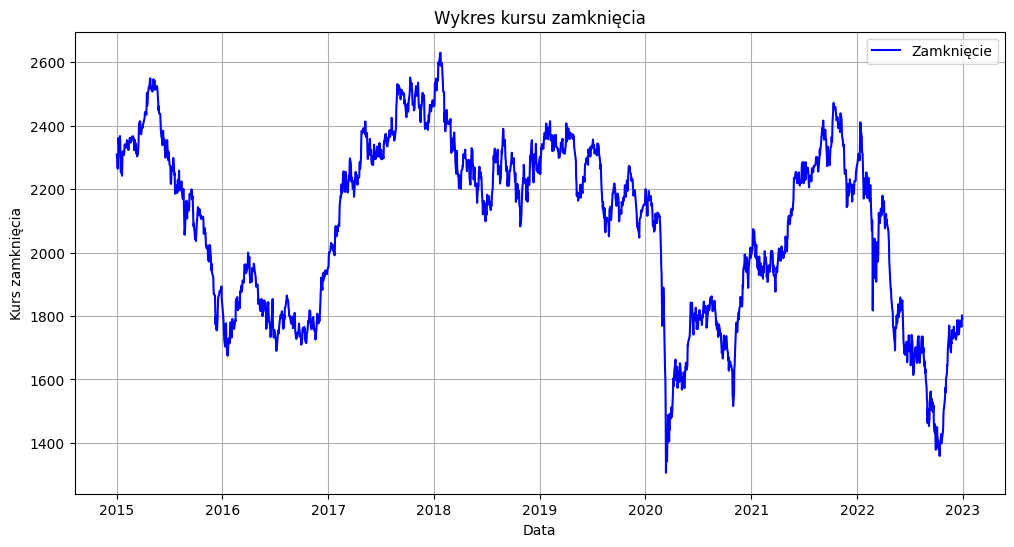

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(data['Data'], data['Zamkniecie'], label='Zamknięcie', color='blue')
plt.xlabel('Data')

plt.ylabel('Kurs zamknięcia')
plt.title('Wykres kursu zamknięcia')
plt.grid(True)
plt.legend()
plt.show()


The chart shows the volatility and cyclicality of the WIG20 index, which is typical for stock markets. It is clearly visible when bull or bear markets occur, as well as the continuous growth in 2017–2018, reflecting Poland's strong economic situation at the time (high GDP, low unemployment).

Particularly noticeable is the onset of the global COVID-19 pandemic, which caused a significant market crash in 2020. Another major geopolitical event is the year 2022, when the war in Ukraine broke out; the stock market reflected societal sentiment and uncertainty, responding with substantial losses.

# Returns

A return is a percentage measure showing the ratio of profit to invested capital over a given period. It allows one to assess the change in asset value and evaluate investment performance.

## Simple Returns

Represents the ratio of net gains from an investment during a period (usually a year) to the invested capital. It is calculated using the formula:
 Z(t) = 100 * (X(t) - X(t-1))/X(t-1)

## Logarithmic Returns

Shows the logarithmic change in price and allows returns over multiple periods to be summed. The formula is:

Z(t) = 100 * ln (X(t)/X(t-1))

In [21]:
data['stopy_proste'] = 100 * (data['Zamkniecie'] - data['Zamkniecie'].shift(1)) / data['Zamkniecie'].shift(1)
data['stopy_logarytmiczne'] = 100 * np.log(data['Zamkniecie'] / data['Zamkniecie'].shift(1))

# ponieważ do obliczenia stóp potrzebuję okrestu t & t+1, naturalnie w mojej macierzy rekord o indeksie pierwszym będzie NA, dlatego go usuwam, aby puste dane nie zaburzyły analizy

print(data.isna().sum())
print(data[:1])

data = data.drop(data.index[0])




Data                   0
Otwarcie               0
Najwyzszy              0
Najnizszy              0
Zamkniecie             0
Wolumen                0
stopy_proste           1
stopy_logarytmiczne    1
dtype: int64
           Data  Otwarcie  Najwyzszy  Najnizszy  Zamkniecie    Wolumen  \
2001 2015-01-02    2323.3    2323.93     2306.4     2309.39  6488816.0   

      stopy_proste  stopy_logarytmiczne  
2001           NaN                  NaN  


## Descriptive Statistics of Returns

Before proceeding with further analysis, it is useful to examine the descriptive statistics of WIG20 returns.

In [22]:
stopy = data[['stopy_proste', 'stopy_logarytmiczne']]
statystyki = stopy.agg(['mean', 'std', 'median', 'min', 'max'])
print(statystyki)

skosnosc = stopy.skew()
kurtoza = stopy.kurtosis()

print(skosnosc, kurtoza)

        stopy_proste  stopy_logarytmiczne
mean       -0.003137            -0.012682
std         1.377362             1.384619
median     -0.009251            -0.009252
min       -13.277410           -14.245579
max         8.436546             8.099498
stopy_proste          -0.614851
stopy_logarytmiczne   -0.834393
dtype: float64 stopy_proste           8.250625
stopy_logarytmiczne    9.855271
dtype: float64


## Interpretation of Return Statistics

- **Mean**:
  * Both simple and logarithmic returns show an average daily return close to zero, though slightly negative.
  * The negative mean may reflect the overall downward trend over 2015–2023, which includes the COVID-19 market shock and geopolitical events (e.g., Ukraine war in 2022).

- **Standard Deviation**:
  * Both return types exhibit almost identical volatility.
  * Indicates that the level of daily fluctuations is comparable regardless of whether simple or logarithmic returns are used.

- **Median**:
  * Identical for both return types.
  * Negative median suggests that more days had losses than gains.

- **Minimum / Maximum**:
  * Extreme returns occur, characteristic of equity markets with bull and bear periods.
  * The minimum loss is larger in magnitude than the maximum gain.
  * Difference between logarithmic and simple returns for extreme drops (~0.969%) highlights that log returns amplify large outliers due to the properties of the logarithmic function.

- **Skewness**:
  * Negative skew for both simple and log returns indicates slight left-skewness.
  * The asymmetry is mild but shows more frequent losses than gains.

- **Kurtosis**:
  * Leptokurtic distribution: "fat tails," indicating a higher likelihood of extreme returns than in a normal distribution.
  * Frequent extreme values, supported by kurtosis values >3.

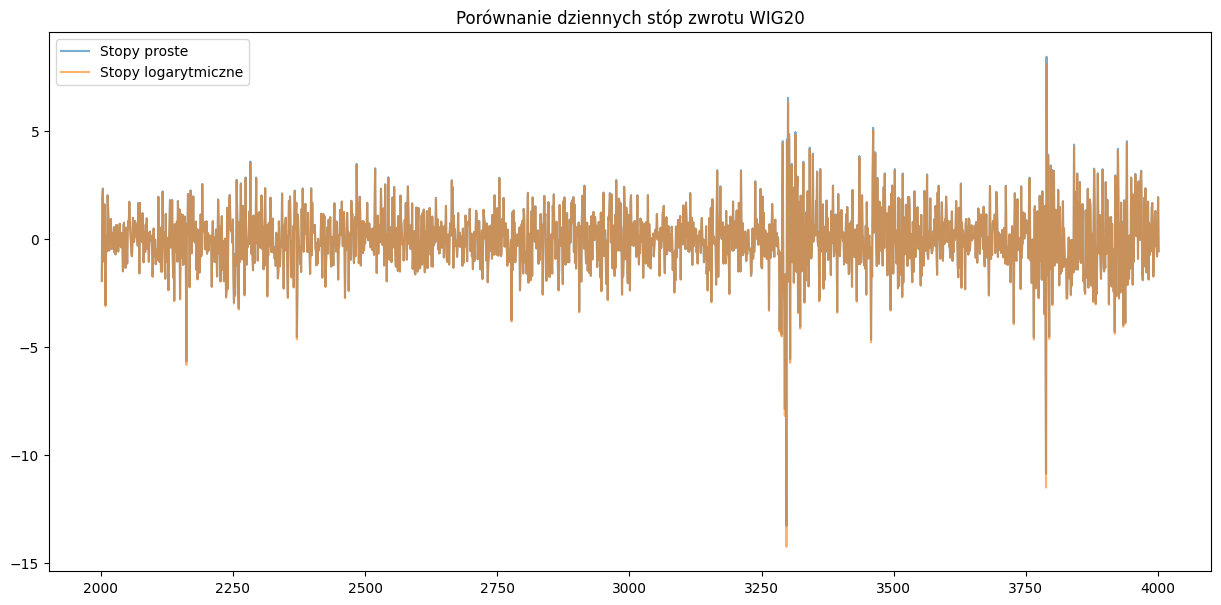

In [23]:
plt.figure(figsize=(15, 7))
plt.plot(stopy.index, stopy['stopy_proste'], label='Stopy proste', alpha=0.6)
plt.plot(stopy.index, stopy['stopy_logarytmiczne'], label='Stopy logarytmiczne', alpha=0.6)
plt.title('Porównanie dziennych stóp zwrotu WIG20')
plt.legend()
plt.show()

As observed in the chart, both series almost entirely overlap, indicating very little difference between simple and logarithmic daily returns. Minor differences become noticeable only during extreme values, confirming the earlier analysis of the logarithmic properties.

Volatility is clearly visible throughout the entire period, with phases of relative calm as well as periods of sharp fluctuations.

# Normality Tests

## Jarque–Bera Test

The Jarque–Bera test is based on the skewness and kurtosis of the distribution of the analyzed variable. The hypotheses are as follows:

H0: The return series follows a normal distribution
H1: The return series does not follow a normal distribution

In [24]:
jb_proste = stats.jarque_bera(stopy['stopy_proste'])
jb_log = stats.jarque_bera(stopy['stopy_logarytmiczne'])

print("Stopy proste:")
print("JB =", jb_proste.statistic)
print("P-value =", jb_proste.pvalue)

print("\nStopy logarytmiczne:")
print("JB =", jb_log.statistic)
print("P-value =", jb_log.pvalue)

Stopy proste:
JB = 5766.138417209143
P-value = 0.0

Stopy logarytmiczne:
JB = 8280.282802150357
P-value = 0.0


Since the p-value < 0.05, we reject H0 in favor of H1. This means that the return series does not follow a normal distribution.


## Andersona-Darlinga test
The Anderson-Darling test examines whether a distribution conforms to a normal distribution, placing particular emphasis on the tails.

Hypotheses:

H0: The return series follows a normal distribution
H1: The return series does not follow a normal distribution

In [25]:
ad_proste = stats.anderson(stopy['stopy_proste'], dist='norm')
ad_log = stats.anderson(stopy['stopy_logarytmiczne'], dist='norm')

print("Stopy proste:")
print("Statystyka A^2 =", ad_proste.statistic)
print("Wartości krytyczne:", ad_proste.critical_values)
print("Poziomy istotności:", ad_proste.significance_level)

print("\nStopy logarytmiczne:")
print("Statystyka A^2 =", ad_log.statistic)
print("Wartości krytyczne:", ad_log.critical_values)
print("Poziomy istotności:", ad_log.significance_level)

Stopy proste:
Statystyka A^2 = 13.752225455524695
Wartości krytyczne: [0.575 0.655 0.785 0.916 1.09 ]
Poziomy istotności: [15.  10.   5.   2.5  1. ]

Stopy logarytmiczne:
Statystyka A^2 = 14.399924776053922
Wartości krytyczne: [0.575 0.655 0.785 0.916 1.09 ]
Poziomy istotności: [15.  10.   5.   2.5  1. ]


Since the test statistic A^2 exceeds the critical value for all significance levels (as shown in the table^), we reject H0 in favor of H1 → the return series does not follow a normal distribution.

## Final Conclusion (Normality Tests)

Both the Jarque–Bera test and the Anderson–Darling test unequivocally indicate that daily returns do not satisfy the assumption of a normal distribution, regardless of whether simple or logarithmic returns are used. This finding is consistent with the earlier analysis of skewness and kurtosis.

# Estimating 99% VaR and ES for Daily Returns

## Value at Risk (VaR) and Expected Shortfall (ES)

**Value at Risk (VaR)** quantifies the maximum potential loss an investment might incur over a specified time horizon at a given confidence level. It is a standard measure in financial risk management to understand potential downside risk.

**Expected Shortfall (ES)**, also known as Conditional VaR, measures the average loss **given that the loss exceeds the VaR level**. ES provides additional insight into the tail risk, complementing VaR.

## Simple Historical Method (Unweighted)

The historical method is straightforward: it uses past observed returns to estimate VaR and ES **without assuming any specific distribution**. The underlying assumption is that future returns will behave similarly to past returns.

**Note:** In the following calculations, **logarithmic returns** will be used.

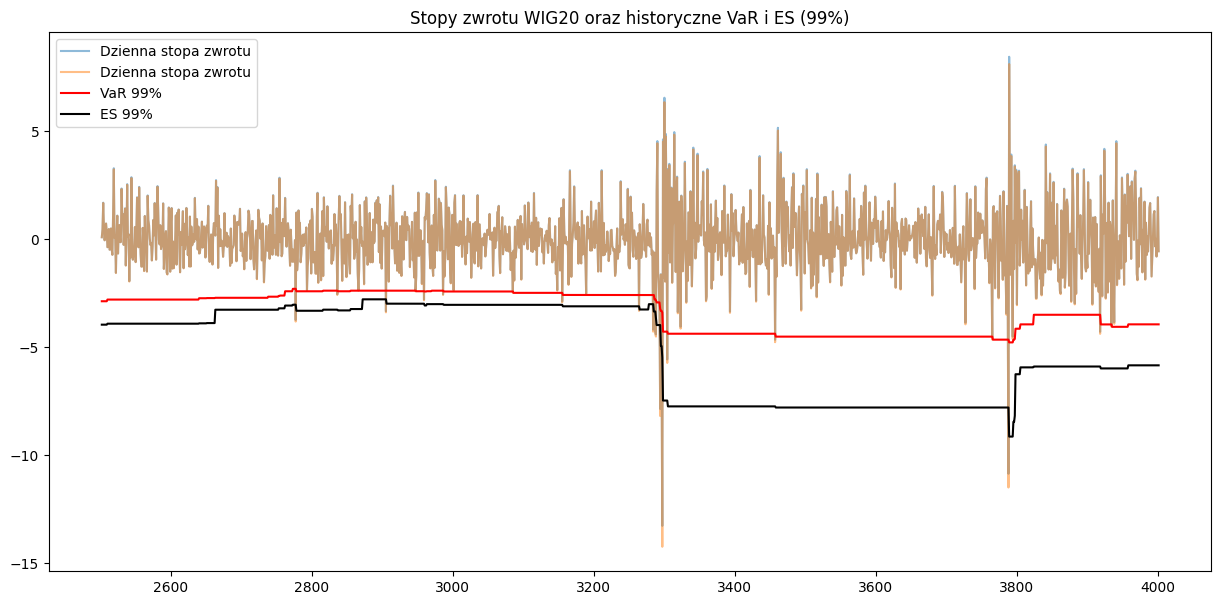

In [26]:
window = 500
alpha = 0.01

VaR_hist = []
ES_hist = []
dates = []

for i in range(window, len(stopy)):
    window_data = stopy['stopy_logarytmiczne'].iloc[i - window:i]

    var_99 = np.quantile(window_data, alpha)
    es_99 = window_data[window_data <= var_99].mean()
    VaR_hist.append(var_99)
    ES_hist.append(es_99)
    dates.append(stopy.index[i])

hist_results = pd.DataFrame({
    'VaR_99_hist': VaR_hist,
    'ES_99_hist': ES_hist
}, index=dates)

aligned_returns = stopy.loc[hist_results.index]

plt.figure(figsize=(15, 7))
plt.plot(aligned_returns.index, aligned_returns, label='Dzienna stopa zwrotu', alpha=0.5)
plt.plot(hist_results.index, hist_results['VaR_99_hist'], label='VaR 99%', color='red')
plt.plot(hist_results.index, hist_results['ES_99_hist'], label='ES 99%', color='black')
plt.title('Stopy zwrotu WIG20 oraz historyczne VaR i ES (99%)')
plt.legend()
plt.show()

As visible in the attached chart, **VaR and ES remain relatively stable**, maintaining a consistent gap between them — the distance between the maximum potential loss (VaR) and the average loss beyond that level (ES) stays fairly constant.

However, this changes during **crisis periods**. The simple historical model struggles to fully capture extreme market movements: it **underestimates the magnitude of losses** during sharp market swings. After the first wave of the global COVID-19 pandemic, the model essentially "learns" from the volatility, lowering both the VaR and ES thresholds, even though the market eventually returned to roughly the same pre-crisis level.

During the next major crisis, the model adapts better, updating its risk estimates more appropriately, but it **still cannot fully reflect sudden, extreme market conditions**, highlighting a limitation of purely historical approaches in periods of high stress.

## EWMA Model

Unlike the classical historical method, the **EWMA (Exponentially Weighted Moving Average) model** accounts for **conditional volatility**, rejecting the assumption of constant variance over time. In EWMA models, the conditional variance is estimated as an **exponentially weighted average** of its past values.


For our analysis, we will apply the **RiskMetrics methodology** with daily updating and a smoothing parameter of **λ = 0.94**.

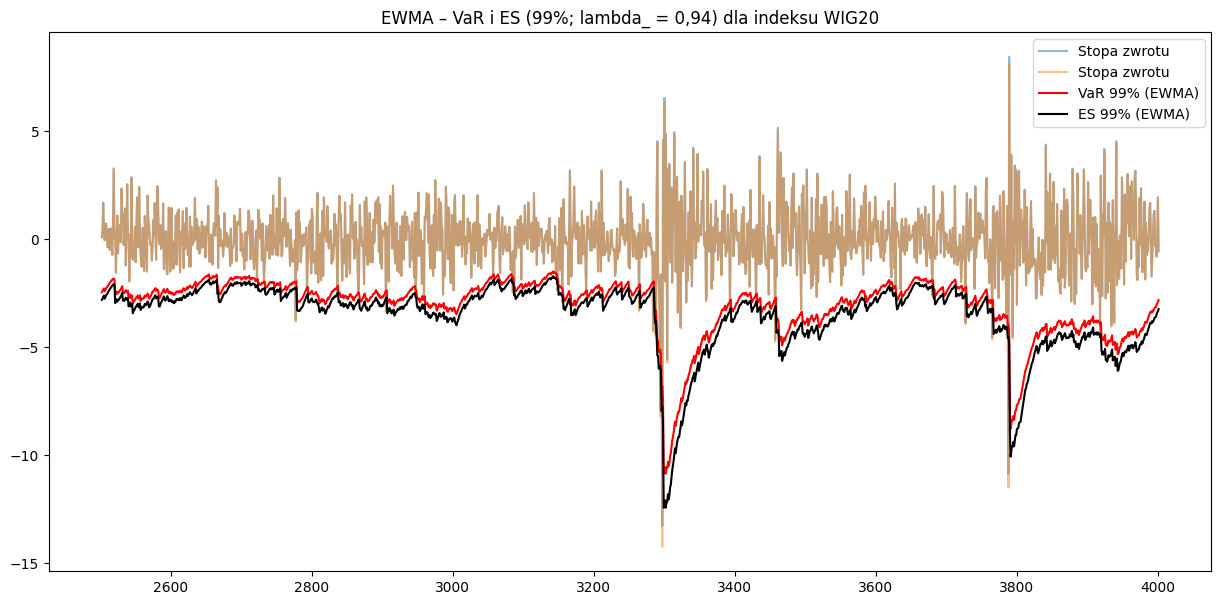

In [27]:
lambda_ = 0.94
window = 500
alpha = 0.01

VaR_ewma = []
ES_ewma = []
dates = []

for i in range(window, len(stopy)):
    window_data = stopy['stopy_logarytmiczne'].iloc[i - window:i]

    # EWMA
    sigma2 = window_data.var()

    for r in window_data[:-1]:
        sigma2 = lambda_ * sigma2 + (1 - lambda_) * r ** 2



    sigma = np.sqrt(sigma2)
    # zakładamy normalność warunkową
    var_99 = stats.norm.ppf(alpha) * sigma
    es_99 = -sigma * stats.norm.pdf(stats.norm.ppf(alpha)) / alpha

    VaR_ewma.append(var_99)
    ES_ewma.append(es_99)
    dates.append(stopy.index[i])

ewma_results = pd.DataFrame({
    'VaR_99_EWMA': VaR_ewma,
    'ES_99_EWMA': ES_ewma
}, index=dates)

aligned_returns = stopy.loc[ewma_results.index]

plt.figure(figsize=(15, 7))
plt.plot(aligned_returns.index, aligned_returns, label='Stopa zwrotu', alpha=0.5)
plt.plot(ewma_results.index, ewma_results['VaR_99_EWMA'], label='VaR 99% (EWMA)', color='red')
plt.plot(ewma_results.index, ewma_results['ES_99_EWMA'], label='ES 99% (EWMA)', color='black')
plt.title('EWMA – VaR i ES (99%; lambda_ = 0,94) dla indeksu WIG20')
plt.legend()
plt.show()


Assuming the presence of **heteroskedasticity**, the EWMA model assigns greater weights to the **most recent observations**, allowing it to respond faster to changes.

As can be seen in the chart, **VaR and ES react more accurately** to shifts while maintaining their relative distance. Overall, this method tends to **understate VaR and ES**, leaving a larger margin of error and making predictions more conservative.

During crisis periods, the model handles situations well, cautiously estimating risks immediately after a market downturn, creating a **slowly declining trend** (a peak with flattening).

### Comparison of Both Methods

**Simple historical method:** During calm periods, VaR and ES change slowly, maintaining a roughly constant distance between them. However, this method **reacts poorly to sudden volatility**. During a crisis, VaR and ES respond with a delay, causing the risk metrics to be **underestimated**. After the crisis, the model remembers extreme observations for a long time, distorting the reality of the market.

**EWMA method:** Reacts faster and more smoothly to changes in volatility, as can be seen when comparing both charts. VaR and ES adjust almost immediately to increased volatility, **maintaining a stable relationship** between them. EWMA produces more **conservative VaR and ES levels**, especially in crisis situations, leaving a larger safety margin compared to the historical method. On the other hand, in extreme market conditions, it still **underestimates very extreme losses**, although to a lesser degree than the simple historical method.

# Backtesting

The examples above showed that VaR can be calculated in many ways and may yield different values. Which technique is the best? We will find out by **backtesting** our models, which check whether VaR was actually exceeded in reality.

For implementing the tests, I use the `vartests` library [https://pypi.org/project/vartests/0.2.4/](https://pypi.org/project/vartests/0.2.4/); according to the documentation, we need a **violation vector** that indicates whether on a given day the loss exceeded the VaR.

## Kupiec Test

This test checks the **unconditional coverage** of VaR, which means it only examines the **total number of VaR breaches** without analyzing the timing, clustering, or temporal dependence of the breaches. Assumptions:

- H0: VaR is correct
- H1: VaR is incorrect

In [28]:
# tutaj tworzony są liczby przekroczeń potrzebne do funkcji
przekroczenia_hist = (aligned_returns['stopy_logarytmiczne'] < hist_results['VaR_99_hist'])
przekroczenia_ewma = (aligned_returns['stopy_logarytmiczne'] < ewma_results['VaR_99_EWMA'])

print("Przekroczenia:")
print(przekroczenia_hist.sum())
print(przekroczenia_ewma.sum())

print("\nMetoda historyczna:")
kupiec_hist = vartests.kupiec_test(
    przekroczenia_hist,
    var_conf_level=0.99,
    conf_level=0.99
)
print(kupiec_hist)

print("\nModel EWMA:")
kupiec_ewma = vartests.kupiec_test(
    przekroczenia_ewma,
    var_conf_level=0.99,
    conf_level=0.99
)
print(kupiec_ewma)

Przekroczenia:
23
28

Metoda historyczna:
{'log-likelihood': np.float64(3.7055999262280395), 'chi square critical value': np.float64(6.634896601021215), 'null hypothesis': 'Probability of failure is 0.01', 'result': 'Fail to reject H0'}

Model EWMA:
{'log-likelihood': np.float64(9.066779573238932), 'chi square critical value': np.float64(6.634896601021215), 'null hypothesis': 'Probability of failure is 0.01', 'result': 'Reject H0'}


For the historical method, H0 was **not rejected**, which means that the VaR is correct. From the perspective of the test, the historical method is reliable.

In the case of the EWMA model, H0 was **rejected**. The EWMA model incorrectly estimates risk, most likely **underestimating the VaR**, which leads to too frequent breaches in the actual data.

Based on the Kupiec test, we can conclude that the historical method provides proper risk coverage, while the EWMA model does not meet this criterion. These results show that despite the greater flexibility of the EWMA model and its faster reaction to volatility changes, it does not always translate into a statistically accurate estimation of the VaR level. The difference amounted to **five breaches**.

## Christoffersen Test

As mentioned earlier, the Kupiec test does not provide any information about the **temporal distribution** of consecutive breaches. In a correct model, VaR breaches should occur **independently over time**. A lack of independence, often manifested as excessive clustering of breaches in one period and excessive dispersion in another, indicates that the VaR model is not functioning properly. Unlike the Kupiec test, the Christoffersen test analyzes the **time structure** of these breaches.

Hypotheses:
H0: VaR breaches are independent over time
H1: VaR breaches are not independent

In [29]:
print("Test Christoffersena")

print("Metoda historyczna:")
duration_hist = vartests.duration_test(
    przekroczenia_hist,
    conf_level=0.99
)
print(duration_hist)

print("\nEWMA:")
duration_ewma = vartests.duration_test(
    przekroczenia_ewma,
    conf_level=0.99
)
print(duration_ewma)

Test Christoffersena
Metoda historyczna:
CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
{'weibull exponential': array([0.60067489]), 'unrestricted log-likelihood': array([-108.32097157]), 'restricted log-likelihood': array([-113.90524788]), 'log-likelihood': array([11.16855261]), 'log-likelihood ratio test statistic': array([0.00083196]), 'null hypothesis': 'Duration Between Exceedances have no memory (Weibull b=1 = Exponential)', 'decision': 'Reject H0'}

EWMA:
CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
{'weibull exponential': array([0.79626093]), 'unrestricted log-likelihood': array([-132.73459531]), 'restricted log-likelihood': array([-133.97535507]), 'log-likelihood': array([2.48151951]), 'log-likelihood ratio test statistic': array([0.11519092]), 'null hypothesis': 'Duration Between Exceedances have no memory (Weibull b=1 = Exponential)', 'decision': 'Fail to Reject H0'}


In the case of the historical method, the null hypothesis H0 was rejected. This indicates that VaR breaches are **not independent** — they tend to cluster over time. From a stock market perspective, this is typical: periods of high volatility generate series of losses exceeding VaR. In practice, this means that while the historical method accurately counts exceptions, it does not handle the **dynamics of risk over time**.

The EWMA model does not provide grounds to reject H0. Breaches can be considered **independent**, which suggests that the model responds better to a changing market and adjusts more effectively to stock market conditions.

<br>

### Brief conclusions from the tests

**Historical method:**
* Satisfies unconditional VaR coverage well
* Does not ensure independence of breaches

**EWMA model:**
* Does not satisfy the correct frequency of breaches
* Better reflects the temporal variability of risk

None of the analyzed models simultaneously meets all the criteria for a correct VaR model.

# Final Conclusions

1. The empirical analysis of returns showed that both simple and logarithmic returns exhibit **negative skewness** and **high kurtosis**, indicating fat tails and a large number of extreme values.
2. Conducted normality tests confirmed the **non-normality** of the distributions, which is characteristic behavior for stock markets.
3. Comparing both types of returns revealed **minimal differences** between them. For extreme observations, logarithmic returns accentuate outliers more strongly.
4. The historical method provided **stable estimates** of VaR and ES but has limitations in **quickly reacting** to price changes, especially during crises.
5. The EWMA model demonstrated **greater sensitivity** to market changes and adjusts better during periods of high volatility.
6. The Kupiec test showed that the historical method provides **correct unconditional VaR coverage**, whereas the EWMA model **fails this criterion**, indicating too many exceedances.
7. The Christoffersen test showed that for the historical method, VaR exceedances are **time-dependent**, whereas for the EWMA model there is **no evidence to reject the hypothesis of independence**, meaning breaches can be considered independent over time.